In [23]:
import numpy as np
import pandas as pd
from variable_leverage_env_1 import agentDLVEnvV2
import os
import shutil
import random
from utils import plot_episode_history_v2, plot_metrics_v2, plot_economic_metrics, plot
from scipy.stats import norm

In [24]:
def w_empirical(residuals, p=0.02):
    """
    residuals : np.ndarray
        Detrended time series residuals
    p : float
        Target intervention probability (e.g. 0.02 for 2%)
    Returns
    -------
    float : empirical band width w
    """
    lower = np.percentile(residuals, p/2*100)
    upper = np.percentile(residuals, 100 - p/2*100)
    return upper - lower

def w_gaussian(sigma, p=0.02):
    """
    sigma : float
        Standard deviation of residuals
    p : float
        Target intervention probability (e.g. 0.02 for 2%)
    Returns
    -------
    float : theoretical band width w
    """
    z = norm.ppf(1 - p/2)   # quantile
    return 2 * sigma * z

In [25]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

action scale 0.9
primordial penalty 0.9
penalty damping 0.95
reward scale 2
reward bound 2
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1


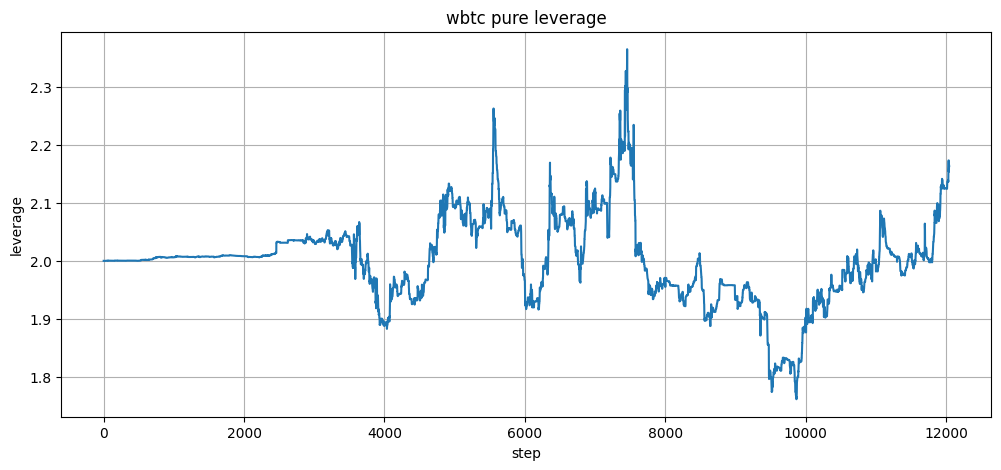

In [26]:
eval_env= agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage=2.1,
    bottom_leverage=1.9
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = 0
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

wbtc_leverage = info['episode_history']['leverage']
plot(None, wbtc_leverage, 'step', 'leverage', 'wbtc pure leverage')

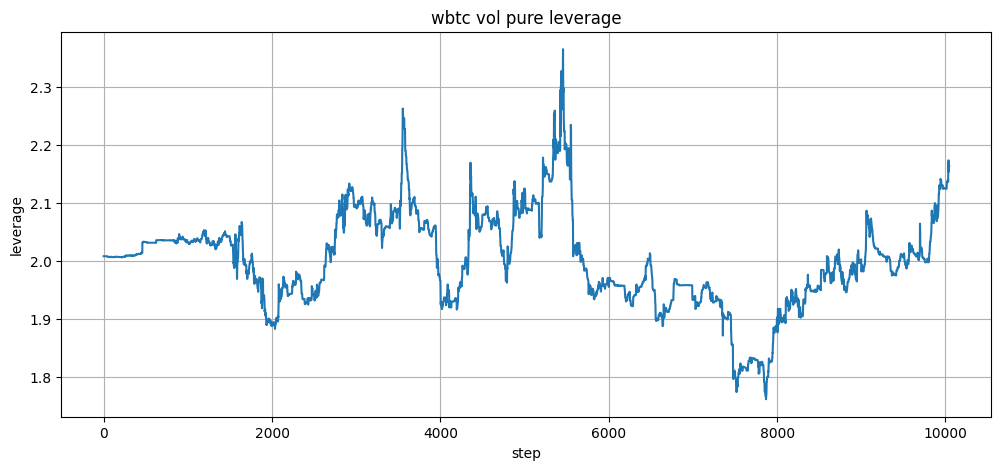

wbtc leverage sigma: 0.08111770728760144
width gauss 2% 0.37741601179115764
width gauss 5% 0.3179755695843222
width gauss 10% 0.2668535100839982
width empirical 2% 0.41040850059592016
width empirical 5% 0.3501022923304071
width empirical 10% 0.2549202425347499


In [27]:
wbtc_leverage_vol = wbtc_leverage[2000:]
plot(None, wbtc_leverage_vol, 'step', 'leverage', 'wbtc vol pure leverage')
sigma_wbtc = np.std(wbtc_leverage_vol)
print('wbtc leverage sigma:', sigma_wbtc)
print('width gauss 2%', w_gaussian(sigma_wbtc, 0.02))
print('width gauss 5%', w_gaussian(sigma_wbtc, 0.05))
print('width gauss 10%', w_gaussian(sigma_wbtc, 0.1))
print('width empirical 2%', w_empirical(wbtc_leverage_vol, 0.02))
print('width empirical 5%', w_empirical(wbtc_leverage_vol, 0.05))
print('width empirical 10%', w_empirical(wbtc_leverage_vol, 0.1))

In [28]:
df = pd.read_csv('weth_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['weth_price'].values
volatile_part = df['weth_frac'].values

nav = nav[::5]
nect_price = nect_price[::5]
vol_token_price = vol_token_price[::5]
volatile_part = volatile_part[::5]

action scale 0.9
primordial penalty 0.9
penalty damping 0.95
reward scale 2
reward bound 2
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1


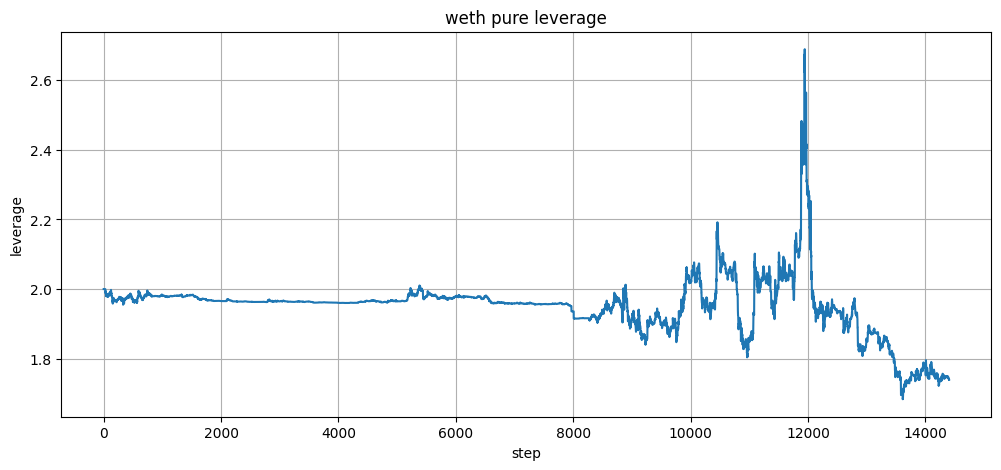

In [29]:
eval_env= agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage=2.1,
    bottom_leverage=1.9
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = 0
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

weth_leverage = info['episode_history']['leverage']
plot(None, weth_leverage, 'step', 'leverage', 'weth pure leverage')

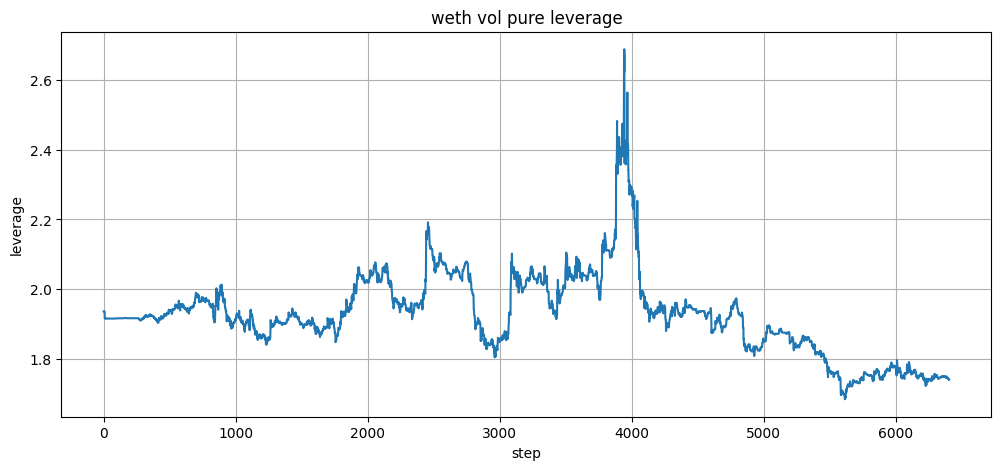

weth leverage sigma: 0.11852053944747963
width gauss 2% 0.5514400099476356
width gauss 5% 0.4645919774906377
width gauss 10% 0.3898978783568638
width empirical 2% 0.6574122207875976
width empirical 5% 0.4355019996425278
width empirical 10% 0.3527920680939618


In [30]:
weth_leverage_vol = weth_leverage[8000:]
plot(None, weth_leverage_vol, 'step', 'leverage', 'weth vol pure leverage')
sigma_weth = np.std(weth_leverage_vol)
print('weth leverage sigma:', sigma_weth)
print('width gauss 2%', w_gaussian(sigma_weth, 0.02))
print('width gauss 5%', w_gaussian(sigma_weth, 0.05))
print('width gauss 10%', w_gaussian(sigma_weth, 0.1))
print('width empirical 2%', w_empirical(weth_leverage_vol, 0.02))
print('width empirical 5%', w_empirical(weth_leverage_vol, 0.05))
print('width empirical 10%', w_empirical(weth_leverage_vol, 0.1))

In [31]:
df = pd.read_csv('wbera_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['wbera_price'].values
vol_token_price = df['wbera_price'].values
volatile_part = df['wbera_frac'].values

nav = nav[::5]
nect_price = nect_price[::5]
vol_token_price = vol_token_price[::5]
volatile_part = volatile_part[::5]

action scale 0.9
primordial penalty 0.9
penalty damping 0.95
reward scale 2
reward bound 2
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1


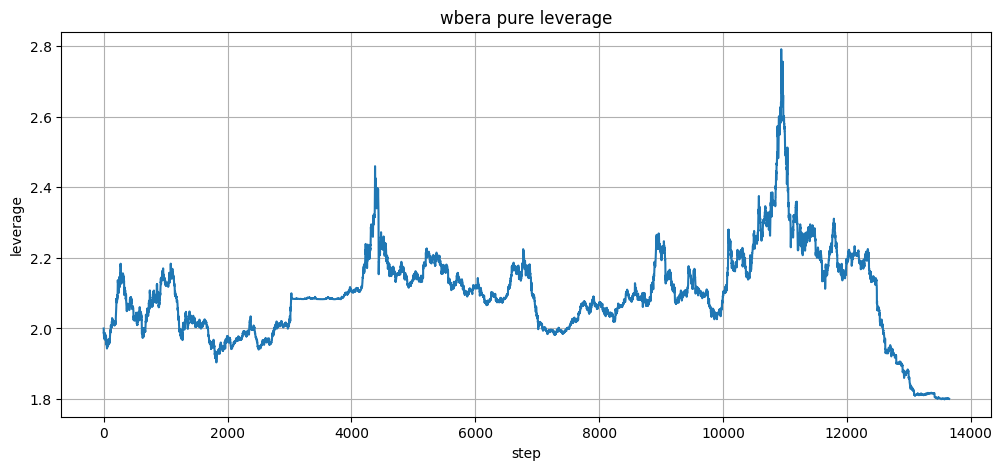

In [32]:
eval_env= agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage=2.1,
    bottom_leverage=1.9
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = 0
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

wbera_leverage = info['episode_history']['leverage']
plot(None, wbera_leverage, 'step', 'leverage', 'wbera pure leverage')

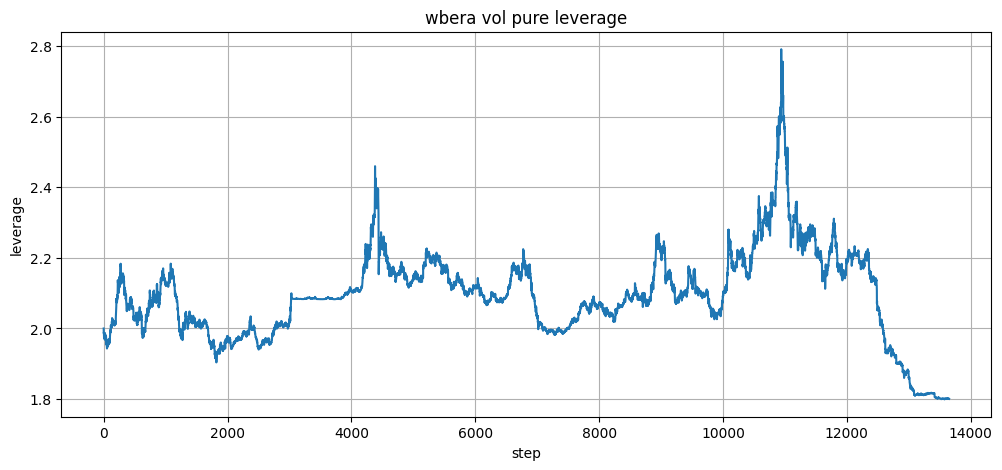

wbera leverage sigma: 0.12540139854690618
width gauss 2% 0.5834545538226867
width gauss 5% 0.49156444952577916
width gauss 10% 0.4125338904493314
width empirical 2% 0.6910399822604449
width empirical 5% 0.5360745851941444
width empirical 10% 0.4132965206864869


In [33]:
wbera_leverage_vol = wbera_leverage
plot(None, wbera_leverage_vol, 'step', 'leverage', 'wbera vol pure leverage')
sigma_wbera = np.std(wbera_leverage_vol)
print('wbera leverage sigma:', sigma_wbera)
print('width gauss 2%', w_gaussian(sigma_wbera, 0.02))
print('width gauss 5%', w_gaussian(sigma_wbera, 0.05))
print('width gauss 10%', w_gaussian(sigma_wbera, 0.1))
print('width empirical 2%', w_empirical(wbera_leverage_vol, 0.02))
print('width empirical 5%', w_empirical(wbera_leverage_vol, 0.05))
print('width empirical 10%', w_empirical(wbera_leverage_vol, 0.1))